# Fake or real? Using AI to detect whether images are real or generated by AI.


In [46]:
import requests
import os
from datetime import datetime

def download_ai_face():
    # URL of the AI-generated face
    url = "https://thispersondoesnotexist.com"
    
    # Create images directory if it doesn't exist
    if not os.path.exists('images'):
        os.makedirs('images')
    
    try:
        # Get the image
        response = requests.get(url)
        response.raise_for_status()  # Raise an exception for bad status codes
        
        # Generate unique filename with timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"images/ai_person_{timestamp}.jpg"
        
        # Save the image
        with open(filename, 'wb') as f:
            f.write(response.content)
        
        print(f"Image downloaded successfully as {filename}")
        return filename
    
    except requests.RequestException as e:
        print(f"Error downloading image: {e}")
        return None

# Call the function
generated_image = download_ai_face()

Image downloaded successfully as images/ai_person_20250605_111206.jpg


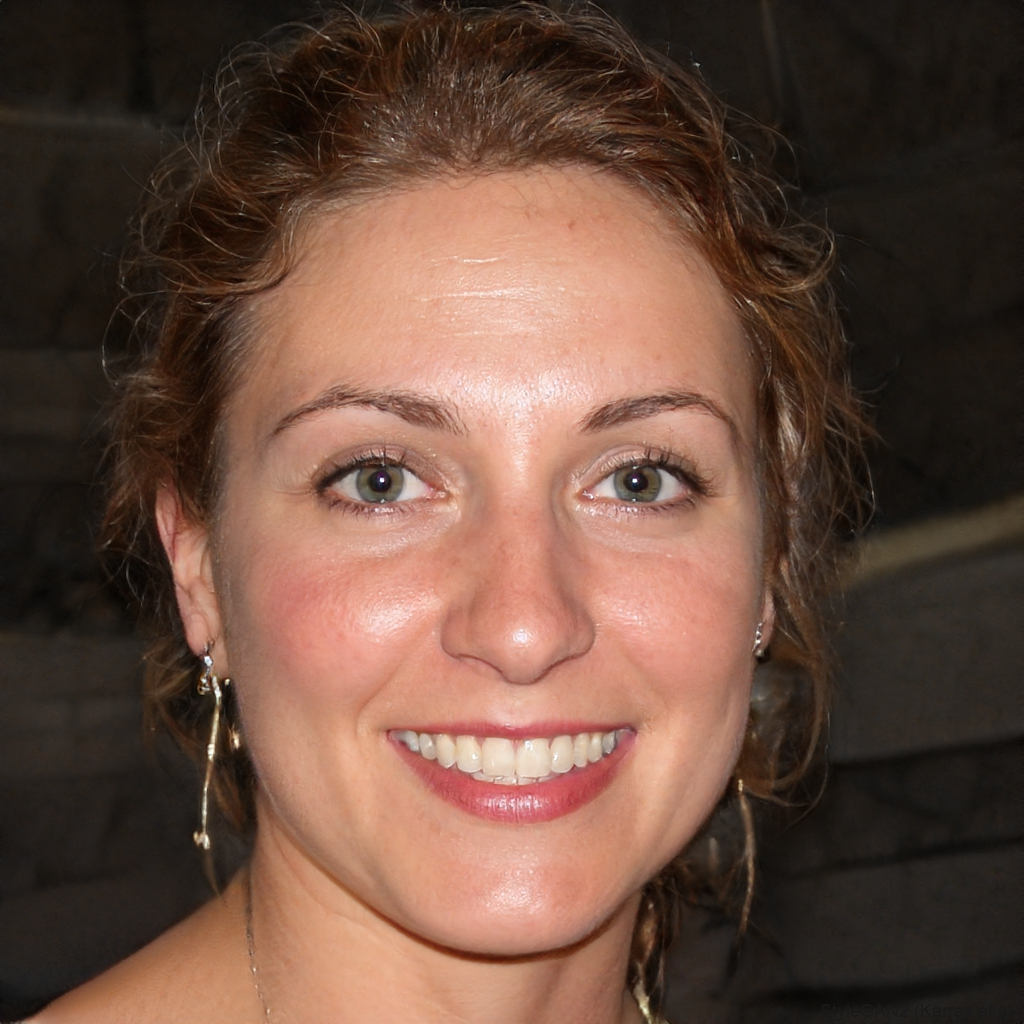

In [47]:
import glob
import IPython
image_list = glob.glob('images/*.jpg')
image_list.sort(key=os.path.getmtime, reverse=True)
selected_image = image_list[0]

IPython.display.Image(selected_image, width=300)  # Display the most recent image

Cropped image saved as images/ai_person_20250605_111206_cropped.jpg


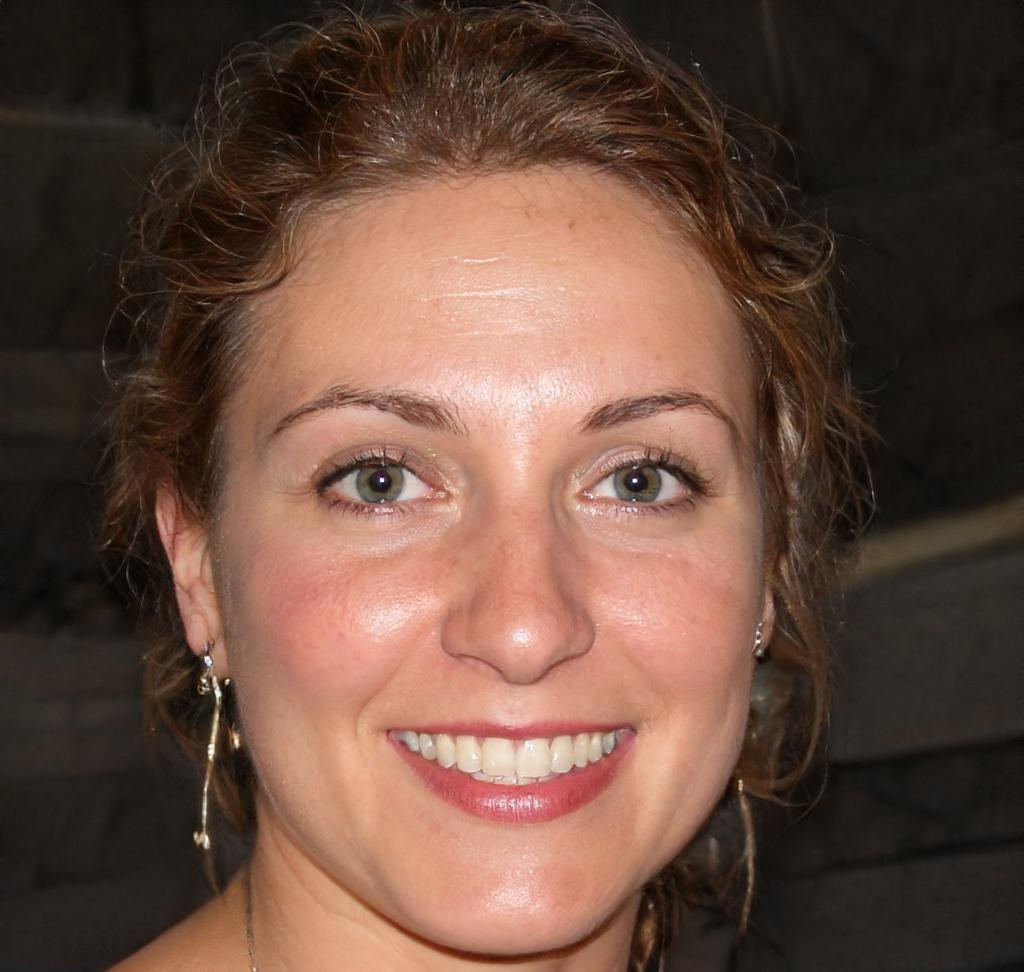

In [48]:
from PIL import Image

image_path = selected_image

def crop_bottom(image_path):
    # Open the image
    img = Image.open(image_path)
    
    # Get dimensions
    width, height = img.size
    
    # Calculate new height (95% of original)
    new_height = int(height * 0.95)
    
    # Crop the image
    cropped_img = img.crop((0, 0, width, new_height))
    
    # Generate output filename
    output_path = image_path.replace('.jpg', '_cropped.jpg')
    
    # Save the cropped image
    cropped_img.save(output_path)
    print(f"Cropped image saved as {output_path}")
    return output_path

# Crop the selected image
cropped_image = crop_bottom(selected_image)

# Display the cropped image
IPython.display.Image(cropped_image, width=300)

## Call the model Claude

In [49]:
#Initialize the Anthropic API client

import anthropic
import config

client = anthropic.Anthropic(
    # defaults to os.environ.get("ANTHROPIC_API_KEY")
    api_key=config.ANTHROPIC_API_KEY,
)


In [52]:
import base64

# Read and encode image
with open(cropped_image, "rb") as f:
    image_data = base64.b64encode(f.read()).decode()

# Call API
response = client.messages.create(
    model="claude-4-sonnet-20250514",
    max_tokens=1000,
    messages=[{
        "role": "user",
        "content": [
            {
                "type": "image",
                "source": {
                    "type": "base64",
                    "media_type": "image/jpeg",
                    "data": image_data
                }
            },
            {"type": "text", "text": "Give me arguments why this image is ai generated and give me arguments why this image is real. Then give me a final conclusion."}
        ]
    }]
)

IPython.display.Image(cropped_image, width=300)  # Display the cropped image
print(response.content[0].text)

I can analyze this image for potential AI generation indicators, but I should note that distinguishing AI-generated content is becoming increasingly difficult as technology advances.

**Arguments suggesting AI generation:**
- The lighting appears very even and possibly artificially balanced
- The skin texture, while detailed, has a somewhat "smoothed" quality in places
- The background is quite blurred/generic, which is common in AI portraits
- Hair texture could appear slightly artificial upon close inspection
- The overall composition is very centered and "portrait-perfect"

**Arguments suggesting it's a real photograph:**
- Natural asymmetries in facial features are present
- Realistic skin imperfections and texture variations
- Natural-looking hair with appropriate flyaways and texture
- Authentic lighting reflections in the eyes
- Jewelry appears to have realistic metallic properties and shadows
- Natural expression and genuine smile
- Appropriate depth of field for a camera photo